# Cardiovascular disease diagnosis using cardiac magnetic resonance radiomics and machine learning


Introduction:
Cardiovascular diseases (CVD) persist as the leading cause of mortality, accounting for
approximately one third of all deaths [1]. Their assessment is usually performed by means
of cardiac magnetic resonance (CMR), the reference imaging modality for studying cardiac
function and structure. Traditionally, few parameters, such as ejection fraction and volumes,
are calculated from the CMR and evaluated by the medical professionals. Despite the
importance of these traditional indexes, they fail to capture the full complexity of the
cardiac tissue. For this reason, in recent years, radiomics has emerged as a novel image
analysis technique to assess CMR [2, 3]. Radiomics involves extracting a high number of
features that characterize the shape, intensity, and texture of the structures of interest.
Project Aim:
In this project, your aim is to leverage machine learning to automatically classify patients'
examinations into five distinct classes using as predictors cardiac magnetic resonance
radiomics.

In [12]:
# Imports compilation

import pandas as pd
import numpy as np


In [1]:
import pandas as pd

df = pd.read_csv('ACDC_radiomics.csv')

## **EDA**:
Display the first few rows of the DataFrame to verify that it was loaded correctly.



### Data exploration

Subtasks:
 - basic data shape description
      - data shape, type...
      - target variable 'class' (balanced)
 - distribution of each feature (compute all and visualize some) [descriptive statistics]
 - distribution of features filtering by class
 ...
 - analyze relationships between Shape & Structure, Structure & radiomic...



### Basic data shape distribution


In [6]:
def basic_eda(df):
    """
    Perform a basic exploratory data analysis on the provided DataFrame,
    excluding verbose descriptive statistics due to the large number of features.
    """
    # 0. Head
    print(display(df.head()))

    # 1. Shape
    print("Shape:", df.shape)

    # 2.1 Missing values per column
    missing = df.isnull().sum()
    print("\nMissing values:")
    print("Missing values per column: ",missing[missing > 0])

    #2.2 Percentage of missing data
    missing_percent = (missing[missing > 0] / len(df)) * 100
    print("Missing values percentage: ",missing_percent)

    # 3. Class distribution
    if 'class' in df.columns:
        print("\nClass distribution:")
        print(df['class'].value_counts())



# testing the function basic_eda on our data frame
basic_eda(df)

,original_shape_Elongation_LV_ED,original_shape_Flatness_LV_ED,original_shape_LeastAxisLength_LV_ED,original_shape_MajorAxisLength_LV_ED,original_shape_Maximum2DDiameterColumn_LV_ED,original_shape_Maximum2DDiameterRow_LV_ED,original_shape_Maximum2DDiameterSlice_LV_ED,original_shape_Maximum3DDiameter_LV_ED,original_shape_MeshVolume_LV_ED,original_shape_MinorAxisLength_LV_ED,...,original_glszm_ZonePercentage_MYO_ES,original_glszm_ZoneVariance_MYO_ES,original_ngtdm_Busyness_MYO_ES,original_ngtdm_Coarseness_MYO_ES,original_ngtdm_Complexity_MYO_ES,original_ngtdm_Contrast_MYO_ES,original_ngtdm_Strength_MYO_ES,height,weight,class
0,0.560917,0.110560,6.592758,59.630582,45.398238,64.776539,64.007812,65.199693,5674.000000,33.447817,...,0.053567,40384.123570,19.552355,0.000993,36.034390,0.010496,0.091329,184,95,DCM
1,0.454960,0.088323,5.730218,64.877933,40.311289,64.140471,61.000000,67.446275,5015.833333,29.516875,...,0.028344,130808.332098,29.225756,0.000722,17.238110,0.006596,0.045024,160,70,DCM
2,0.541682,0.105418,6.711577,63.666027,48.041649,66.843100,59.135438,68.080834,7817.666667,34.486772,...,0.041404,92088.926893,20.732684,0.001106,13.916093,0.004455,0.069372,165,77,DCM
3,0.487949,0.105906,6.726159,63.510529,44.407207,66.370174,66.007575,66.475559,5629.166667,30.989912,...,0.150855,5232.431686,5.158496,0.000848,216.183657,0.025431,0.208797,159,46,DCM
4,0.442150,0.095225,7.186765,75.471150,68.066144,77.472576,50.487622,77.472576,8550.083333,33.369563,...,0.040613,91705.803093,18.086404,0.000710,41.886924,0.005266,0.123346,165,77,DCM


None
Shape: (100, 645)

Missing values:
Missing values per column:  Series([], dtype: int64)
Missing values percentage:  Series([], dtype: float64)

Class distribution:
class
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


### Groupping and in-depth EDA

Feature naming in data:

**original_RadiomicCategory_FeatureName_Structure_Phase**


RadiomicCategory: shape, firstorder, glcm, glszm, glrlm, ngtdm, gldm.

Structure: myocardium (MYO), left ventricle (LV), right ventricle (RV).

Phase: end-diastole (ED), end-systole (ES).



In [21]:
# Functions to access a group of features from the data
def extract_features_nominally(df, category=None, structure=None, phase=None):
    """Returns columns matching specified filters."""
    cols = df.columns
    if category:
        cols = [col for col in cols if f'_{category}_' in col]
    if structure:
        cols = [col for col in cols if f'_{structure}_' in col]
    if phase:
        cols = [col for col in cols if col.endswith(f'_{phase}')]
    return cols


# try extract_features
# glcm_lv_es_features = extract_features_nominally(df, category='glcm', structure='LV', phase='ES')
# df[glcm_lv_es_features].describe().T

# another example
# lv_es_features = extract_features_nominally(df, structure='LV', phase='ES')
# df[lv_es_features].describe().T



#### Experiment classification with different feature grouppings

In [29]:
# prompt: i want to set up a workshop for experimentation: the experiments must compare the performance of classification models on several subsets of the data frame. This subsets will be determined/encoded by all the possible partitions of the data nominally with the function extract_features_nominally

from itertools import product

def setup_workshop(df):
    """
    Sets up an experimentation workshop for comparing classification model performance
    on different subsets of the dataframe.
    """

    # Define feature categories, structures, and phases for experimentation
    categories = ['shape', 'firstorder', 'glcm', 'glszm', 'glrlm', 'ngtdm', 'gldm']
    structures = ['MYO', 'LV', 'RV']
    phases = ['ED', 'ES']

    # Generate all possible combinations of filters
    all_combinations = list(product([None] + categories, [None] + structures, [None] + phases))
    all_combinations.remove((None, None, None))


    experiment_setups = []
    for category, structure, phase in all_combinations:

        # Extract features for each combination
        features = extract_features_nominally(df, category=category, structure=structure, phase=phase)

        #Check if the features subset is not empty
        if features:
            #create the experiment setup
            experiment_setups.append({
            'description': f'Category: {category}, Structure: {structure}, Phase: {phase}',
            'features': features
        })

    return experiment_setups



[{'description': 'Category: None, Structure: None, Phase: ED', 'features': ['original_shape_Elongation_LV_ED', 'original_shape_Flatness_LV_ED', 'original_shape_LeastAxisLength_LV_ED', 'original_shape_MajorAxisLength_LV_ED', 'original_shape_Maximum2DDiameterColumn_LV_ED', 'original_shape_Maximum2DDiameterRow_LV_ED', 'original_shape_Maximum2DDiameterSlice_LV_ED', 'original_shape_Maximum3DDiameter_LV_ED', 'original_shape_MeshVolume_LV_ED', 'original_shape_MinorAxisLength_LV_ED', 'original_shape_Sphericity_LV_ED', 'original_shape_SurfaceArea_LV_ED', 'original_shape_SurfaceVolumeRatio_LV_ED', 'original_shape_VoxelVolume_LV_ED', 'original_firstorder_10Percentile_LV_ED', 'original_firstorder_90Percentile_LV_ED', 'original_firstorder_Energy_LV_ED', 'original_firstorder_Entropy_LV_ED', 'original_firstorder_InterquartileRange_LV_ED', 'original_firstorder_Kurtosis_LV_ED', 'original_firstorder_Maximum_LV_ED', 'original_firstorder_MeanAbsoluteDeviation_LV_ED', 'original_firstorder_Mean_LV_ED', 'ori

We now have all possible combinations of groups of features that make sense to group accoring to what they represent.


We will now train this subsets on a baseline simple model and compare their accuracy

In [33]:
from sklearn.ensemble import RandomForestClassifier

def train_simple_model(X_train, y_train):
    """
    Trains a RandomForestClassifier model on the provided training data.

    This function creates and trains a Random Forest Classifier using the
    scikit-learn library. It takes the training features (X_train) and
    corresponding target labels (y_train) as input, trains the model,
    and returns the trained classifier.

    Args:
        X_train (pandas.DataFrame or numpy.ndarray): The training features.
        y_train (pandas.Series or numpy.ndarray): The target labels for training.

    Returns:
        sklearn.ensemble.RandomForestClassifier: The trained Random Forest Classifier model.
    """

    # 1. Create a RandomForestClassifier model
    #    - random_state=42 ensures consistent results across runs
    model = RandomForestClassifier(random_state=42)

    # 2. Train the model on the provided training data
    #    - This is where the model learns patterns from the data
    model.fit(X_train, y_train)

    # 3. Return the trained model for later use (e.g., making predictions)
    return model

In [37]:
# prompt: modify this code so that in the train model part of the function it calls to another function named 'train_model(X_train,y_train) which given a X_train,y_train) returns a trained model :

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def evaluate_subsets(df, experiment_setups):
    """
    Evaluates classification model performance on different feature subsets.
    """
    results = []
    for setup in experiment_setups:
        features = setup['features']
        description = setup['description']
        # Prepare data
        X = df[features]
        y = df['class']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        # Train model using the external function train_simple_model
        model = train_simple_model(X_train, y_train)
        # Make predictions
        y_pred = model.predict(X_test)
        # Evaluate model
        accuracy = accuracy_score(y_test, y_pred)
        # Store results
        results.append({'description': description, 'accuracy': accuracy})
    return results


[{'description': 'Category: None, Structure: None, Phase: ED', 'features': ['original_shape_Elongation_LV_ED', 'original_shape_Flatness_LV_ED', 'original_shape_LeastAxisLength_LV_ED', 'original_shape_MajorAxisLength_LV_ED', 'original_shape_Maximum2DDiameterColumn_LV_ED', 'original_shape_Maximum2DDiameterRow_LV_ED', 'original_shape_Maximum2DDiameterSlice_LV_ED', 'original_shape_Maximum3DDiameter_LV_ED', 'original_shape_MeshVolume_LV_ED', 'original_shape_MinorAxisLength_LV_ED', 'original_shape_Sphericity_LV_ED', 'original_shape_SurfaceArea_LV_ED', 'original_shape_SurfaceVolumeRatio_LV_ED', 'original_shape_VoxelVolume_LV_ED', 'original_firstorder_10Percentile_LV_ED', 'original_firstorder_90Percentile_LV_ED', 'original_firstorder_Energy_LV_ED', 'original_firstorder_Entropy_LV_ED', 'original_firstorder_InterquartileRange_LV_ED', 'original_firstorder_Kurtosis_LV_ED', 'original_firstorder_Maximum_LV_ED', 'original_firstorder_MeanAbsoluteDeviation_LV_ED', 'original_firstorder_Mean_LV_ED', 'ori

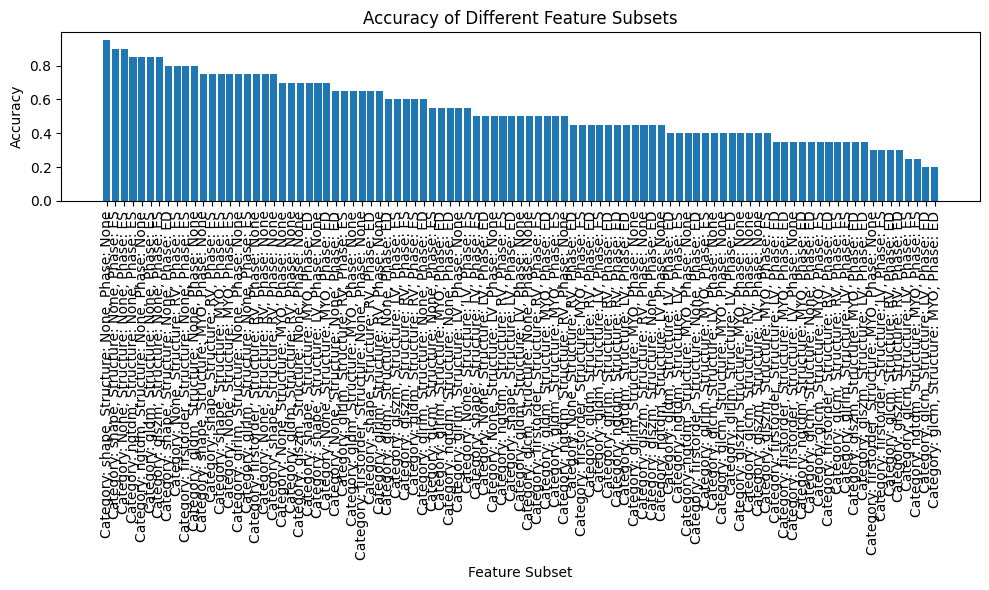

In [39]:

# Create experiment setup for the groupped features comparison:
experiment_setups = setup_workshop(df)
print(experiment_setups)

# Run the evaluation and print the results
results = evaluate_subsets(df, experiment_setups)

# Create a DataFrame from the results
results_df = pd.DataFrame(results)
# print(results_df)

# Sort the results DataFrame by accuracy in descending order
results_df_sorted = results_df.sort_values(by='accuracy', ascending=False)

# Print the sorted results
print("\nSorted Results:")
print(results_df_sorted)

# Plotting the results (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(results_df_sorted['description'], results_df_sorted['accuracy'])
plt.xlabel("Feature Subset")
plt.ylabel("Accuracy")
plt.title("Accuracy of Different Feature Subsets")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()




In [41]:
# prompt: print the full list of results_df_sorted

results_df_sorted


,description,accuracy
11,"Category: shape, Structure: None, Phase: None",0.95
13,"Category: shape, Structure: None, Phase: ES",0.90
1,"Category: None, Structure: None, Phase: ES",0.90
73,"Category: ngtdm, Structure: None, Phase: ES",0.85
71,"Category: ngtdm, Structure: None, Phase: None",0.85
...,...,...
57,"Category: glszm, Structure: RV, Phase: ED",0.30
43,"Category: glcm, Structure: LV, Phase: ES",0.25
76,"Category: ngtdm, Structure: MYO, Phase: ES",0.25
42,"Category: glcm, Structure: LV, Phase: ED",0.20


from matplotlib import pyplot as plt
results_df_sorted['accuracy'].plot(kind='hist', bins=20, title='accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_df_sorted['accuracy'].plot(kind='line', figsize=(8, 4), title='accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

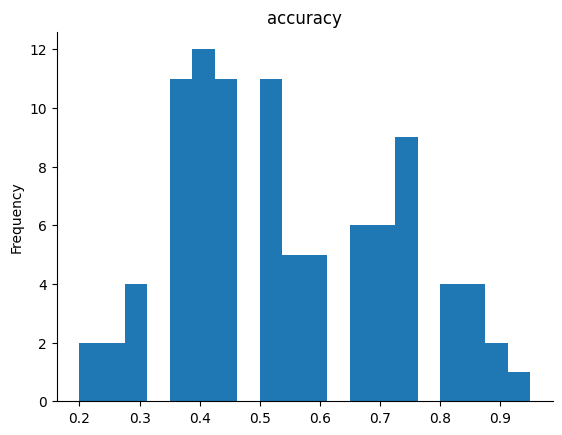

In [42]:
from matplotlib import pyplot as plt
results_df_sorted['accuracy'].plot(kind='hist', bins=20, title='accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

#### Groupping experiment results interpretation

The best performing subsets of features seem to be shape and ED, a radiomic feature with a phase... also some grayscale radiomics features seem to be very informative. There is a clear overrepresentation of ED features among the best performing data subsets.

On the other hand, subsets with the 3 labels specified perform significantly worse likely due to holding less information. Specially grey matrixes and first order radiomics.

Further questions can be easily answered regading the significance of specific subsets of the dataset (for instanc, which has performed better between RV, LV or both?)

##### Further rabbithole groupping analysis

In [43]:
# prompt: given the results, compare the average accuracy between the subsets trained with RV features, the subsets trained with LV features and those trained with both (with bothe -> 'None')

# Calculate the average accuracy for each feature type
rv_accuracy = results_df_sorted[results_df_sorted['description'].str.contains('Structure: RV')]['accuracy'].mean()
lv_accuracy = results_df_sorted[results_df_sorted['description'].str.contains('Structure: LV')]['accuracy'].mean()
both_accuracy = results_df_sorted[results_df_sorted['description'].str.contains('Structure: None')]['accuracy'].mean()

print(f"Average accuracy for RV features: {rv_accuracy}")
print(f"Average accuracy for LV features: {lv_accuracy}")
print(f"Average accuracy for both features: {both_accuracy}")

# Compare the average accuracies
if rv_accuracy > lv_accuracy and rv_accuracy > both_accuracy:
    print("RV features have the highest average accuracy.")
elif lv_accuracy > rv_accuracy and lv_accuracy > both_accuracy:
    print("LV features have the highest average accuracy.")
elif both_accuracy > rv_accuracy and both_accuracy > lv_accuracy:
    print("Combined features have the highest average accuracy.")
else:
    print("There is a tie in average accuracy between feature sets.")


Average accuracy for RV features: 0.5458333333333334
Average accuracy for LV features: 0.43333333333333335
Average accuracy for both features: 0.6978260869565218
Combined features have the highest average accuracy.


Further exploration ideas:

- Find a way of discovering which labels have the most synergy (when they are both present in the subset the accuracy is higher than when only one or none is present)
Also, find the contrary: which labels are repellent (both present in the subset makes it have less accuracy than the other cases).
Example:
in the subsets that have RV and shape they have better accuracy than in those with only RV (not shape, first order or another radiomics metric) or only shape (LV [note that None means that all labels are present so counts as RV as well])

## Data split, train v- validation

Stratification (n_splits = 5)

Possible improvements:
- tune/decide n_splits
- aside from train and test, put some validation data apart with hold out method


In [ ]:
# basic split of the data
X = df.drop('class', axis=1)
y = df['class']

##### Stratified KV

In [ ]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# function to help further understanding the process
def print_class_distribution(X,y):
  folds = []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
      print(f"Fold {fold + 1}")
      print(f"Train samples: {len(train_idx)}, Validation samples: {len(val_idx)}")
      print("Class distribution in validation set:")
      print(y.iloc[val_idx].value_counts())
      print("-" * 40)
      folds.append((train_idx, val_idx))

print_class_distribution(X,y)

Fold 1
Train samples: 80, Validation samples: 20
Class distribution in validation set:
class
DCM     4
HCM     4
MINF    4
NOR     4
RV      4
Name: count, dtype: int64
----------------------------------------
Fold 2
Train samples: 80, Validation samples: 20
Class distribution in validation set:
class
DCM     4
HCM     4
MINF    4
NOR     4
RV      4
Name: count, dtype: int64
----------------------------------------
Fold 3
Train samples: 80, Validation samples: 20
Class distribution in validation set:
class
DCM     4
HCM     4
MINF    4
NOR     4
RV      4
Name: count, dtype: int64
----------------------------------------
Fold 4
Train samples: 80, Validation samples: 20
Class distribution in validation set:
class
DCM     4
HCM     4
MINF    4
NOR     4
RV      4
Name: count, dtype: int64
----------------------------------------
Fold 5
Train samples: 80, Validation samples: 20
Class distribution in validation set:
class
DCM     4
HCM     4
MINF    4
NOR     4
RV      4
Name: count, dtyp

### Test with RandomForestClassufier example model

In [ ]:
avg_score = 0

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    score = model.score(X_val, y_val)
    print(f"Fold {fold + 1} Accuracy: {score:.2f}")
    avg_score += score

avg_score /= n_splits
print(f"Average Accuracy: {avg_score:.2f}")


Fold 1 Accuracy: 0.80
Fold 2 Accuracy: 0.70
Fold 3 Accuracy: 0.80
Fold 4 Accuracy: 0.85
Fold 5 Accuracy: 0.85
Average Accuracy: 0.80


Questions & decisions:

- n_splits ? which value
- stratified vs non stratified? (is the sample stratified too small?)

## Model experimentation

- basic experiments, they should be improved

In [ ]:
# prompt: entrena un svm con los datos y validalo con skf, pon este proceso en una funcion; llama a esta funcion en una serie de experimentos

from sklearn.svm import SVC

def run_svm_experiment(X, y, n_splits=5, kernel='linear', C=1.0):
    """
    Trains an SVM model using StratifiedKFold cross-validation and prints the results.

    Args:
        X: Features DataFrame
        y: Target variable Series
        n_splits: Number of splits for StratifiedKFold
        kernel: Kernel type for the SVM
        C: Regularization parameter for the SVM
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    avg_score = 0

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = SVC(kernel=kernel, C=C)
        model.fit(X_train, y_train)
        score = model.score(X_val, y_val)
        print(f"Fold {fold + 1} Accuracy: {score:.2f}")
        avg_score += score

    avg_score /= n_splits
    print(f"Average Accuracy: {avg_score:.2f}")


# Example usage with different experimental setups
experiments = [
    {'kernel': 'linear', 'C': 1.0},
    {'kernel': 'rbf', 'C': 1.0},
    {'kernel': 'poly', 'C': 1.0},
    {'kernel': 'linear', 'C': 0.1},
    {'kernel': 'rbf', 'C': 10.0},
]

for i, exp in enumerate(experiments):
    print(f"Experiment {i + 1}: {exp}")
    run_svm_experiment(X, y, kernel=exp['kernel'], C=exp['C'])
    print("-" * 40)


Experiment 1: {'kernel': 'linear', 'C': 1.0}
Fold 1 Accuracy: 0.80
Fold 2 Accuracy: 0.75
Fold 3 Accuracy: 0.80
Fold 4 Accuracy: 0.95
Fold 5 Accuracy: 0.90
Average Accuracy: 0.84
----------------------------------------
Experiment 2: {'kernel': 'rbf', 'C': 1.0}
Fold 1 Accuracy: 0.40
Fold 2 Accuracy: 0.50
Fold 3 Accuracy: 0.35
Fold 4 Accuracy: 0.25
Fold 5 Accuracy: 0.35
Average Accuracy: 0.37
----------------------------------------
Experiment 3: {'kernel': 'poly', 'C': 1.0}
Fold 1 Accuracy: 0.35
Fold 2 Accuracy: 0.30
Fold 3 Accuracy: 0.25
Fold 4 Accuracy: 0.20
Fold 5 Accuracy: 0.25
Average Accuracy: 0.27
----------------------------------------
Experiment 4: {'kernel': 'linear', 'C': 0.1}
Fold 1 Accuracy: 0.80
Fold 2 Accuracy: 0.75
Fold 3 Accuracy: 0.80
Fold 4 Accuracy: 0.95
Fold 5 Accuracy: 0.90
Average Accuracy: 0.84
----------------------------------------
Experiment 5: {'kernel': 'rbf', 'C': 10.0}
Fold 1 Accuracy: 0.55
Fold 2 Accuracy: 0.50
Fold 3 Accuracy: 0.65
Fold 4 Accuracy: 0.6

In [ ]:
# prompt: entrena un k nearest neighbours con los datos y validalo con skf , pon que se pueda cambiar con un parametro cuentos neighbours hay; llama a la funcion en una serie de experimentos con los parametros; pon mas parametros para tunear el modelo de el basico n_neighbors

from sklearn.neighbors import KNeighborsClassifier

def run_knn_experiment(X, y, n_splits=5, n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski'):
    """
    Trains a KNN model using StratifiedKFold cross-validation and prints the results.

    Args:
        X: Features DataFrame
        y: Target variable Series
        n_splits: Number of splits for StratifiedKFold
        n_neighbors: Number of neighbors to use by default for kneighbors queries
        weights: weight function used in prediction
        algorithm: Algorithm used to compute the nearest neighbors
        leaf_size: Leaf size passed to BallTree or KDTree
        p: Power parameter for the Minkowski metric
        metric: the distance metric to use for the tree
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    avg_score = 0

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, algorithm=algorithm, leaf_size=leaf_size, p=p, metric=metric)
        model.fit(X_train, y_train)
        score = model.score(X_val, y_val)
        print(f"Fold {fold + 1} Accuracy: {score:.2f}")
        avg_score += score

    avg_score /= n_splits
    print(f"Average Accuracy: {avg_score:.2f}")


# Example usage with different experimental setups
experiments = [
    {'n_neighbors': 3},
    {'n_neighbors': 5},
    {'n_neighbors': 7, 'weights': 'distance'},
    {'n_neighbors': 5, 'algorithm': 'kd_tree'},
    {'n_neighbors': 7, 'leaf_size' : 10},
    {'n_neighbors': 7, 'p': 1, 'metric': 'minkowski'},
]

for i, exp in enumerate(experiments):
    print(f"Experiment {i + 1}: {exp}")
    run_knn_experiment(X, y, **exp)
    print("-" * 40)


Experiment 1: {'n_neighbors': 3}
Fold 1 Accuracy: 0.55
Fold 2 Accuracy: 0.60
Fold 3 Accuracy: 0.70
Fold 4 Accuracy: 0.65
Fold 5 Accuracy: 0.65
Average Accuracy: 0.63
----------------------------------------
Experiment 2: {'n_neighbors': 5}
Fold 1 Accuracy: 0.45
Fold 2 Accuracy: 0.55
Fold 3 Accuracy: 0.60
Fold 4 Accuracy: 0.60
Fold 5 Accuracy: 0.45
Average Accuracy: 0.53
----------------------------------------
Experiment 3: {'n_neighbors': 7, 'weights': 'distance'}
Fold 1 Accuracy: 0.50
Fold 2 Accuracy: 0.65
Fold 3 Accuracy: 0.80
Fold 4 Accuracy: 0.75
Fold 5 Accuracy: 0.70
Average Accuracy: 0.68
----------------------------------------
Experiment 4: {'n_neighbors': 5, 'algorithm': 'kd_tree'}
Fold 1 Accuracy: 0.45
Fold 2 Accuracy: 0.55
Fold 3 Accuracy: 0.60
Fold 4 Accuracy: 0.60
Fold 5 Accuracy: 0.45
Average Accuracy: 0.53
----------------------------------------
Experiment 5: {'n_neighbors': 7, 'leaf_size': 10}
Fold 1 Accuracy: 0.40
Fold 2 Accuracy: 0.35
Fold 3 Accuracy: 0.60
Fold 4 Ac

#### Precise parameter selection for each model

Grid Search: Grid search is a more systematic approach where you define a grid of parameter values and evaluate the model for each combination. It's more comprehensive but can be computationally expensive for large search spaces.

Randomized Search: Randomized search samples parameter values randomly from a defined distribution. It's often more efficient than grid search for finding good parameter settings, especially for large search spaces.

Bayesian Optimization: Bayesian optimization uses a probabilistic model to guide the search for optimal parameters. It's particularly effective for complex and expensive-to-evaluate objective functions.

Genetic Algorithms: Genetic algorithms are inspired by natural selection and evolution. They evolve a population of parameter settings, iteratively selecting and combining the best-performing ones to find optimal solutions.



In [ ]:
# prompt: the function run_knn_experiment is ok but i'd like to find the most optimum parameters with better methods like for example:
# Grid Search, Randomized Search, Bayesian Optimization, Genetic Algorithms

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint, uniform

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 20, 30, 40],
    'p': [1, 2],
    'metric': ['minkowski', 'euclidean', 'manhattan']
}

# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_neighbors': randint(3, 12),  # Random integer between 3 and 11
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': randint(10, 41),  # Random integer between 10 and 40
    'p': [1, 2],
    'metric': ['minkowski', 'euclidean', 'manhattan']
}


def run_knn_experiment_with_search(X, y, search_type='grid', n_splits=5, **kwargs):
    """
    Trains a KNN model using either GridSearchCV or RandomizedSearchCV and prints the results.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    knn = KNeighborsClassifier()

    if search_type == 'grid':
        search = GridSearchCV(knn, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
    elif search_type == 'random':
        search = RandomizedSearchCV(knn, param_distributions, cv=skf, scoring='accuracy', n_jobs=-1, n_iter=20) # Adjust n_iter as needed
    else:
        raise ValueError("Invalid search_type. Choose 'grid' or 'random'.")

    search.fit(X, y)

    print(f"Best parameters: {search.best_params_}")
    print(f"Best cross-validation score: {search.best_score_}")
    return search.best_estimator_


# Example usage
best_knn_grid = run_knn_experiment_with_search(X, y, search_type='grid')
best_knn_random = run_knn_experiment_with_search(X, y, search_type='random')

print("-" * 40)
print("Grid Search Best KNN Model:")
print(best_knn_grid)

print("-" * 40)
print("Randomized Search Best KNN Model:")
best_knn_random


Best parameters: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.7200000000000001
Best parameters: {'algorithm': 'kd_tree', 'leaf_size': 28, 'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.7200000000000001
----------------------------------------
Grid Search Best KNN Model:
KNeighborsClassifier(leaf_size=10, n_neighbors=3, p=1, weights='distance')
----------------------------------------
Randomized Search Best KNN Model:


KNeighborsClassifier(algorithm='kd_tree', leaf_size=28, n_neighbors=3, p=1,
                     weights='distance')

In [ ]:
# prompt: # prompt: change run_knn_experiment_with_search so that it can apply for any model

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform

def run_experiment_with_search(X, y, model, param_grid, search_type='grid', n_splits=5, **kwargs):
    """
    Trains a model using either GridSearchCV or RandomizedSearchCV and prints the results.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    if search_type == 'grid':
        search = GridSearchCV(model, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
    elif search_type == 'random':
        search = RandomizedSearchCV(model, param_grid, cv=skf, scoring='accuracy', n_jobs=-1, n_iter=20) # Adjust n_iter as needed
    else:
        raise ValueError("Invalid search_type. Choose 'grid' or 'random'.")

    search.fit(X, y)

    print(f"Best parameters: {search.best_params_}")
    print(f"Best cross-validation score: {search.best_score_}")
    return search.best_estimator_

# Example usage with RandomForestClassifier

param_grid_rf_grid = {
    'n_estimators': [100,150,200],
    #'max_depth': [10, 20, 30],
    #'min_samples_split': [2, 4, 6,8,10],
    'min_samples_split': [4,6],
    'min_samples_leaf': [1, 2]
}

param_grid_rf_random = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

best_rf_grid = run_experiment_with_search(X, y, RandomForestClassifier(), param_grid_rf_grid, search_type='grid')
#best_rf_random = run_experiment_with_search(X, y, RandomForestClassifier(), param_grid_rf_random, search_type='random')


print("-" * 40)
print("Randomized Search Best RandomForest Model:")


Best parameters: {'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}
Best cross-validation score: 0.8300000000000001
----------------------------------------
Randomized Search Best RandomForest Model:


In [ ]:
best_rf_random = run_experiment_with_search(X, y, RandomForestClassifier(), param_grid_rf_random, search_type='random')

Best parameters: {'max_depth': 36, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 62}
Best cross-validation score: 0.82


#### Idea:

Try parameter ranges with random search and then with the results try grid

In [ ]:
# prompt: def run_experiment_with_search(X, y, model, param_grid, search_type='grid', n_splits=5, **kwargs):
#     """
#     Trains a model using either GridSearchCV or RandomizedSearchCV and prints the results.
#     """
#     skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
#     if search_type == 'grid':
#         search = GridSearchCV(model, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
#     elif search_type == 'random':
#         search = RandomizedSearchCV(model, param_grid, cv=skf, scoring='accuracy', n_jobs=-1, n_iter=20) # Adjust n_iter as needed
#     else:
#         raise ValueError("Invalid search_type. Choose 'grid' or 'random'.")
#     search.fit(X, y)
#     print(f"Best parameters: {search.best_params_}")
#     print(f"Best cross-validation score: {search.best_score_}")
#     return search.best_estimator_
# Try this with the Bayesian Optimization for the parameters method

!pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

def run_experiment_with_bayes_search(X, y, model, search_spaces, n_splits=5, n_iter=20, **kwargs):
    """
    Trains a model using BayesSearchCV and prints the results.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    search = BayesSearchCV(
        model,
        search_spaces,
        n_iter=n_iter,
        cv=skf,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )
    search.fit(X, y)
    print(f"Best parameters: {search.best_params_}")
    print(f"Best cross-validation score: {search.best_score_}")
    return search.best_estimator_

# Example usage with RandomForestClassifier
param_grid_rf_bayes = {
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(10, 50),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5)
}

best_rf_bayes = run_experiment_with_bayes_search(X, y, RandomForestClassifier(), param_grid_rf_bayes)

print("-" * 40)
print("Bayesian Optimization Best RandomForest Model:")
best_rf_bayes


Best parameters: OrderedDict([('max_depth', 50), ('min_samples_leaf', 4), ('min_samples_split', 3), ('n_estimators', 116)])
Best cross-validation score: 0.82
----------------------------------------
Bayesian Optimization Best RandomForest Model:


RandomForestClassifier(max_depth=50, min_samples_leaf=4, min_samples_split=3,
                       n_estimators=116)

## Feature analysis and dimensionality reduction

In [ ]:
# prompt: Feature Engineering and Model Enhancement: Develop a pipeline that includes a
# dimensionality reduction or feature selection technique or a combination of both
# approaches as a prior step to classification.
# Encapsulate in a function or several functions this process

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

def feature_engineering_pipeline(X, y, method='pca', n_components=10, k_best=10):
    """
    Applies dimensionality reduction or feature selection to the input data.

    Args:
        X: Feature DataFrame.
        y: Target variable Series.
        method: Dimensionality reduction method ('pca' or 'kbest').
        n_components: Number of components for PCA.
        k_best: Number of top features to select using k-best.

    Returns:
        Transformed feature DataFrame.
    """
    if method == 'pca':
        pca = PCA(n_components=n_components)
        X_transformed = pca.fit_transform(X)
        return pd.DataFrame(X_transformed)  # Convert to DataFrame
    elif method == 'kbest':
        selector = SelectKBest(score_func=f_classif, k=k_best)
        X_transformed = selector.fit_transform(X, y)
        return pd.DataFrame(X_transformed) # Convert to DataFrame
    else:
        raise ValueError("Invalid method specified. Choose 'pca' or 'kbest'.")


# Example usage (after defining X and y as in the original code)
X_pca = feature_engineering_pipeline(X, y, method='pca', n_components=20)
#print(X_pca) #Print the new dataframe
run_svm_experiment(X_pca,y) #Test with SVM

X_kbest = feature_engineering_pipeline(X, y, method='kbest', k_best=20)
run_knn_experiment(X_kbest,y) #Test with KNN


Fold 1 Accuracy: 0.80
Fold 2 Accuracy: 0.75
Fold 3 Accuracy: 0.80
Fold 4 Accuracy: 0.95
Fold 5 Accuracy: 0.90
Average Accuracy: 0.84
Fold 1 Accuracy: 0.50
Fold 2 Accuracy: 0.60
Fold 3 Accuracy: 0.45
Fold 4 Accuracy: 0.70
Fold 5 Accuracy: 0.60
Average Accuracy: 0.57


In [ ]:
# prompt: for feature_engineering_pipeline do a more sophysticated method:
# do LDA Linear Discriminant Analysis and combine it with other methods

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

def feature_engineering_pipeline(X, y, method='pca', n_components=10, k_best=10):
    """
    Applies dimensionality reduction or feature selection to the input data.
    Includes LDA as an option.

    Args:
        X: Feature DataFrame.
        y: Target variable Series.
        method: Dimensionality reduction method ('pca', 'kbest', or 'lda').
        n_components: Number of components for PCA or LDA.
        k_best: Number of top features to select using k-best.

    Returns:
        Transformed feature DataFrame.
    """
    if method == 'pca':
        pca = PCA(n_components=n_components)
        X_transformed = pca.fit_transform(X)
        return pd.DataFrame(X_transformed)
    elif method == 'kbest':
        selector = SelectKBest(score_func=f_classif, k=k_best)
        X_transformed = selector.fit_transform(X, y)
        return pd.DataFrame(X_transformed)
    elif method == 'lda':
        lda = LDA(n_components=min(n_components, len(np.unique(y)) - 1)) # n_components <= n_classes - 1
        X_transformed = lda.fit_transform(X, y)
        return pd.DataFrame(X_transformed)
    else:
        raise ValueError("Invalid method specified. Choose 'pca', 'kbest', or 'lda'.")

# Example usage with LDA
X_lda = feature_engineering_pipeline(X, y, method='lda', n_components=1)
run_svm_experiment(X_lda, y)  # Test with SVM

# Combining LDA with other methods (example: combining LDA with kbest)

# 1. Apply LDA
X_lda_transformed = feature_engineering_pipeline(X, y, method='lda', n_components=min(10, len(np.unique(y)) -1))

#2. Apply kbest to the LDA output
X_lda_kbest = feature_engineering_pipeline(X_lda_transformed, y, method='kbest', k_best=5)

run_knn_experiment(X_lda_kbest, y) #Test with KNN


NameError: name 'np' is not defined

In [ ]:
# prompt: try  feature_engineering_pipeline and generate several transformed data; then try this data on the function run_experiment_with_search

# Example usage with different n_components and k_best values for PCA and kbest
n_components_values = [5, 10, 15]
k_best_values = [5, 10, 15]

for n_components in n_components_values:
    X_pca = feature_engineering_pipeline(X, y, method='pca', n_components=n_components)
    print(f"Running experiment with PCA, n_components={n_components}")
    run_experiment_with_search(X_pca, y, RandomForestClassifier(), param_grid_rf_random, search_type='random')
    print("-" * 40)

for k_best in k_best_values:
    X_kbest = feature_engineering_pipeline(X, y, method='kbest', k_best=k_best)
    print(f"Running experiment with kbest, k_best={k_best}")
    run_experiment_with_search(X_kbest, y, RandomForestClassifier(), param_grid_rf_random, search_type='random')
    print("-" * 40)

# Example usage with LDA and different n_components values
n_components_lda_values = [1, 2, 3,4]  # Adjust as needed

for n_components_lda in n_components_lda_values:
    X_lda = feature_engineering_pipeline(X, y, method='lda', n_components=n_components_lda)
    print(f"Running experiment with LDA, n_components={n_components_lda}")
    run_experiment_with_search(X_lda, y, RandomForestClassifier(), param_grid_rf_random, search_type='random')
    print("-" * 40)


Running experiment with PCA, n_components=5
Best parameters: {'max_depth': 21, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 119}
Best cross-validation score: 0.6900000000000001
----------------------------------------
Running experiment with PCA, n_components=10
Best parameters: {'max_depth': 39, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 176}
Best cross-validation score: 0.75
----------------------------------------
Running experiment with PCA, n_components=15
Best parameters: {'max_depth': 35, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 116}
Best cross-validation score: 0.7700000000000001
----------------------------------------
Running experiment with kbest, k_best=5
Best parameters: {'max_depth': 12, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 86}
Best cross-validation score: 0.7100000000000001
----------------------------------------
Running experiment with kbest, k_best=10
Best parameters: {'max_depth': 1

## Extra analysis

#### Further tests: precise parameter selection for each model

Grid Search: Grid search is a more systematic approach where you define a grid of parameter values and evaluate the model for each combination. It's more comprehensive but can be computationally expensive for large search spaces.

Randomized Search: Randomized search samples parameter values randomly from a defined distribution. It's often more efficient than grid search for finding good parameter settings, especially for large search spaces.

Bayesian Optimization: Bayesian optimization uses a probabilistic model to guide the search for optimal parameters. It's particularly effective for complex and expensive-to-evaluate objective functions.

Genetic Algorithms: Genetic algorithms are inspired by natural selection and evolution. They evolve a population of parameter settings, iteratively selecting and combining the best-performing ones to find optimal solutions.

##### Determining Sufficient Generalization
Unfortunately, there's no magic formula to guarantee you've applied enough generalization techniques. However, here are some indicators and practices to guide you:

Stable Validation Performance: When your model's performance on the validation set is consistently good and doesn't fluctuate significantly across different cross-validation folds, it suggests that the model is generalizing well.

Small Performance Gap: A small difference between the training and validation performance is a good sign. A large gap indicates potential overfitting, while a very small or no gap might suggest underfitting. Aim for a balance where the validation performance is slightly lower than the training performance.

Consistent Performance on New Data: If possible, test your model on a separate, unseen dataset (a holdout set) that wasn't used during training or validation. This provides the most realistic estimate of how well your model generalizes to new data.

Hyperparameter Tuning: When using techniques like grid search or randomized search, if the optimal hyperparameters consistently point towards simpler models (e.g., lower tree depth, higher regularization strength), it suggests that you're on the right track in terms of generalization.

Error Analysis: Analyze the types of errors your model is making on the validation set. If the errors are systematic or biased towards certain data points, it might indicate areas where the model is overfitting or not generalizing well. Address these issues with appropriate techniques.

Quantifying Generalizability/Anti-overfitting
Here are some metrics and guidelines for quantifying generalizability and anti-overfitting:

Cross-Validation Score: The average performance across cross-validation folds is a good indicator of generalizability. Higher cross-validation scores suggest better generalization.

Validation Performance Metrics: Choose appropriate performance metrics for your task (e.g., accuracy, precision, recall, F1-score) and evaluate them on the validation set. These metrics provide a quantitative measure of how well your model is generalizing.

Learning Curves: Plot the training and validation performance as a function of training data size. Learning curves can help diagnose overfitting or underfitting. If the validation curve plateaus while the training curve continues to improve, it suggests overfitting.

Generalization Error: This is the difference between the expected error on unseen data and the training error. It's difficult to measure directly, but cross-validation provides an estimate of it.

Complexity Measures: For some models, you can use complexity measures like VC dimension or Rademacher complexity to estimate the model's capacity to overfit. These measures are more theoretical but can provide insights into potential overfitting.

Guidelines for Applying Generalization Techniques
Start with simpler models and gradually increase complexity as needed.
Use regularization techniques to control model complexity.
Apply feature engineering and selection to focus on relevant features.
Employ data augmentation if you have limited data.
Use cross-validation consistently for model evaluation and parameter tuning.
Monitor learning curves to identify potential overfitting.
Analyze errors to understand where the model is struggling and adjust your approach accordingly.

## Pipelines

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline with feature scaling, PCA, and a Random Forest classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Feature scaling
    ('pca', PCA(n_components=20)),  # Dimensionality reduction with PCA
    ('classifier', RandomForestClassifier())  # Random Forest classifier
])

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Predict on the validation data
y_pred = pipeline.predict(X_val)

## Deep learning

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Convert 'class' column to numerical labels
# Assuming 'class' contains strings representing different classes, e.g., 'A', 'B', 'C'
# Create a mapping from unique string labels to integer labels
class_mapping = {label: idx for idx, label in enumerate(df['class'].unique())}
df['class_numerical'] = df['class'].map(class_mapping)
# Now, 'class_numerical' contains integer labels

# Extract features (X) and target (y)
X = df.iloc[:, 0:645].values  # Consider all features
X = df.drop(columns=['class', 'class_numerical']) #drop both string labels and new numerical labels
y = df['class_numerical'].values #use numerical labels

# Convert data to PyTorch tensors
X_nn = torch.from_numpy(X.astype(np.float32).values) # use np.float32
y_nn = torch.tensor(y, dtype=torch.long)  # Assuming 'class' is categorical

# ----------------

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42, stratify=y)




In [ ]:
# prompt: use pytorch to create a neural network to classify the dataset from the 645 features to the 5 classes in the target feature 'class'
# DO sparse categoric cross entropy!!!
# Generate the code to trainning loop and print the loss value and accuracy for every epoch
# I want to know also the training accuracy
# Take into account my data (do the correct conversion to tensors)

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Assuming X_train, X_val, y_train, y_val are already defined as PyTorch tensors

# Define the neural network
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Initialize the network, loss function, and optimizer
input_size = 644  # Number of features
hidden_size = 64  # Number of neurons in the hidden layer
num_classes = 5  # Number of classes
num_epochs = 50  # Number of training epochs

net = Net(input_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss() # Use CrossEntropyLoss
optimizer = optim.Adam(net.parameters(), lr=0.1) # Example optimizer

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    outputs = net(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate training accuracy
    _, predicted_train = torch.max(outputs.data, 1)
    train_accuracy = accuracy_score(y_train, predicted_train)

    # Validation
    with torch.no_grad():
        val_outputs = net(X_val)
        val_loss = criterion(val_outputs, y_val)
        _, predicted_val = torch.max(val_outputs.data, 1)
        val_accuracy = accuracy_score(y_val, predicted_val)

    print(f"Epoch [{epoch + 1}/{num_epochs}], "
          f"Loss: {loss.item():.4f}, "
          f"Train Accuracy: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss.item():.4f}, "
          f"Val Accuracy: {val_accuracy:.4f}")


Epoch [1/50], Loss: 1.7299, Train Accuracy: 0.1375, Val Loss: 2.3300, Val Accuracy: 0.4000
Epoch [2/50], Loss: 2.3178, Train Accuracy: 0.3625, Val Loss: 3.3285, Val Accuracy: 0.2000
Epoch [3/50], Loss: 3.2251, Train Accuracy: 0.2000, Val Loss: 1.4609, Val Accuracy: 0.4500
Epoch [4/50], Loss: 1.3951, Train Accuracy: 0.3875, Val Loss: 1.4796, Val Accuracy: 0.4500
Epoch [5/50], Loss: 1.4881, Train Accuracy: 0.4750, Val Loss: 1.8476, Val Accuracy: 0.5500
Epoch [6/50], Loss: 1.7919, Train Accuracy: 0.5750, Val Loss: 2.1041, Val Accuracy: 0.5500
Epoch [7/50], Loss: 1.9877, Train Accuracy: 0.5875, Val Loss: 2.0459, Val Accuracy: 0.5000
Epoch [8/50], Loss: 1.8965, Train Accuracy: 0.5250, Val Loss: 1.6768, Val Accuracy: 0.6000
Epoch [9/50], Loss: 1.5507, Train Accuracy: 0.6250, Val Loss: 1.2766, Val Accuracy: 0.6500
Epoch [10/50], Loss: 1.2233, Train Accuracy: 0.5750, Val Loss: 0.9754, Val Accuracy: 0.6000
Epoch [11/50], Loss: 0.9590, Train Accuracy: 0.6125, Val Loss: 0.9748, Val Accuracy: 0.55

In [ ]:
# prompt: import torch
# import torch.nn as nn
# import torch.optim as optim
# from sklearn.model_selection import train_test_split
# import pandas as pd
# import numpy as np
# # Assuming your data is in a pandas DataFrame called 'df'
# # with features in columns 0-644 and the target in 'class'
# # Extract features (X) and target (y)
# X = df.iloc[:, 0:645].values # Consider all features
# X = df.drop(columns=['class'])
# y = df['class'].values
# # Convert data to PyTorch tensors
# X_nn = torch.from_numpy(X.astype(np.float32).values)
# y_nn = torch.tensor(y, dtype=torch.long)  # Assuming 'class' is categorical
# Additionally to this code convert y to integers from string

# Convert 'class' column to numerical labels
# Assuming 'class' contains strings representing different classes, e.g., 'A', 'B', 'C'
# Create a mapping from unique string labels to integer labels
class_mapping = {label: idx for idx, label in enumerate(df['class'].unique())}
df['class_numerical'] = df['class'].map(class_mapping)
# Now, 'class_numerical' contains integer labels

# Extract features (X) and target (y)
X = df.iloc[:, 0:645].values  # Consider all features
X = df.drop(columns=['class', 'class_numerical']) #drop both string labels and new numerical labels
y = df['class_numerical'].values #use numerical labels

# Convert data to PyTorch tensors
X_nn = torch.from_numpy(X.astype(np.float32)) # use np.float32
y_nn = torch.tensor(y, dtype=torch.long)  # Assuming 'class' is categorical
